In [39]:
# !pip install lazypredict
# !pip install matplotlib
# !pip install seaborn

### Código para Classificação (LazyClassifier) com suporte ROC AUC em multiclasses

A ROC AUC (Área Sob a Curva ROC) é uma métrica usada para avaliar modelos de classificação, particularmente em problemas binários. É baseada na Curva ROC (Receiver Operating Characteristic), que é um gráfico que mostra a relação entre:

Taxa de verdadeiros positivos (True Positive Rate - TPR): Proporção de instâncias positivas corretamente classificadas.

Taxa de falsos positivos (False Positive Rate - FPR): Proporção de instâncias negativas incorretamente classificadas como positivas.

O valor AUC (Área Under the Curve) mede a área sob essa curva. Ele varia de 0 a 1:

1.0: O modelo é perfeito.

0.5: O modelo não tem capacidade discriminativa (equivalente a um chute aleatório).

< 0.5: O modelo é pior que um chute aleatório.

In [1]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit,train_test_split
from lazypredict.Supervised import LazyClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier


In [ ]:

# Carregar os dados do arquivo
file_path = '../../sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados
df = df.iloc[:50000]

# Função para processar cada eixo independentemente
def process_axis(df, axis_name):
    print(f"\n### Avaliando o eixo {axis_name.upper()} ###")

    # Selecionar os dados do eixo atual
    axis_data = df[axis_name]
    
    # Criar classes temporais respeitando a ordem dos dados
    def rolling_qcut(series, q=5):
        unique_values = series.unique()
        if len(unique_values) < q:
            return pd.cut(series, bins=len(unique_values), labels=False, duplicates="drop").iloc[-1]
        return pd.qcut(series, q=q, labels=False, duplicates="drop").iloc[-1]

    df[f'{axis_name}_class'] = (
        df[axis_name]
        .rolling(window=5000, min_periods=1)
        .apply(lambda x: rolling_qcut(x), raw=False)
        .astype(float) 
        .fillna(method="ffill")
    )

    # Definir as features (X) e o target (y)
    # X = df[[axis_name]]  # Feature: o eixo atual
    # y = df[f'{axis_name}_class'].astype(int)

    # ---------------------------------------------
    # 1) Definir 'n' passos à frente para prever.
    # ---------------------------------------------
    n = 1  # ou outro valor de horizonte de previsão

    # ---------------------------------------------
    # 2) Criar a coluna de classe futura (shiftda).
    # ---------------------------------------------
    df[f'{axis_name}_class_future'] = df[f'{axis_name}_class'].shift(-n)

    # ---------------------------------------------
    # 3) Definir X e y com corte das últimas linhas.
    # ---------------------------------------------
    # X: feature atual (sem as últimas 'n' linhas)
    X = df[[axis_name]].iloc[:-n]

    # y: classe "futura" (sem as linhas que ficaram vazias após shift)
    y = df[f'{axis_name}_class_future'].iloc[:-n].astype(int)

    split_number = 1
    avg_micro_auc, avg_macro_auc = 0, 0  # Para cálculo das médias dos AUCs

    # Configurar o TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)

    for train_index, test_index in tscv.split(X):
        print(f"\n--- Processando Split {split_number} para o eixo {axis_name.upper()} ---")

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Inicializar o LazyClassifier
        clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
        models, predictions = clf.fit(X_train, X_test, y_train, y_test)

        print(f"Modelos avaliados com LazyClassifier (TimeSeriesSplit, eixo {axis_name.upper()}):")
        print(models)

        # Exemplo de como treinar manualmente um classificador específico
        best_model = LGBMClassifier(objective='multiclass', num_class=5, random_state=123, verbosity=-1)
        best_model.fit(X_train, y_train)

        # Obter as probabilidades para calcular ROC AUC
        y_pred_proba = best_model.predict_proba(X_test)

        # Binarizar os rótulos reais
        y_test_binarized = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

        # Calcular o ROC AUC (micro e macro)
        roc_auc_micro = roc_auc_score(y_test_binarized, y_pred_proba, average='micro', multi_class='ovr')
        roc_auc_macro = roc_auc_score(y_test_binarized, y_pred_proba, average='macro', multi_class='ovr')

        avg_micro_auc += roc_auc_micro
        avg_macro_auc += roc_auc_macro

        print(f"ROC AUC (Micro) para o split atual: {roc_auc_micro}")
        print(f"ROC AUC (Macro) para o split atual: {roc_auc_macro}")

        split_number += 1

    # Calcular a média dos AUCs
    avg_micro_auc /= tscv.get_n_splits()
    avg_macro_auc /= tscv.get_n_splits()

    print(f"\nMédia do ROC AUC (Micro) para o eixo {axis_name.upper()}: {avg_micro_auc}")
    print(f"Média do ROC AUC (Macro) para o eixo {axis_name.upper()}: {avg_macro_auc}")

    return avg_micro_auc, avg_macro_auc

# Avaliar todos os eixos independentes
metrics_x = process_axis(df, 'x')
metrics_y = process_axis(df, 'y')
metrics_z = process_axis(df, 'z')

# Comparar os resultados
print("\n### Comparação Final dos Resultados ###")
print(f"Média do ROC AUC (Micro): X={metrics_x[0]}, Y={metrics_y[0]}, Z={metrics_z[0]}")
print(f"Média do ROC AUC (Macro): X={metrics_x[1]}, Y={metrics_y[1]}, Z={metrics_z[1]}")



### Avaliando o eixo X ###

--- Processando Split 1 para o eixo X ---


100%|██████████| 32/32 [00:14<00:00,  2.26it/s]


Modelos avaliados com LazyClassifier (TimeSeriesSplit, eixo X):
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
PassiveAggressiveClassifier        0.20               0.21    None      0.11   
LGBMClassifier                     0.21               0.21    None      0.19   
XGBClassifier                      0.21               0.20    None      0.18   
ExtraTreeClassifier                0.21               0.20    None      0.18   
ExtraTreesClassifier               0.21               0.20    None      0.18   
DecisionTreeClassifier             0.21               0.20    None      0.18   
RandomForestClassifier             0.21               0.20    None      0.18   
Perceptron                         0.20               0.20    None      0.11   
NearestCentroid                    0.21               0.20    None      0.12   
SGDClassifier                      0.21               0.

100%|██████████| 32/32 [00:34<00:00,  1.07s/it]


Modelos avaliados com LazyClassifier (TimeSeriesSplit, eixo X):
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
SGDClassifier                      0.20               0.21    None      0.15   
NuSVC                              0.21               0.21    None      0.20   
ExtraTreeClassifier                0.21               0.20    None      0.19   
DecisionTreeClassifier             0.21               0.20    None      0.19   
ExtraTreesClassifier               0.21               0.20    None      0.19   
BaggingClassifier                  0.21               0.20    None      0.18   
RandomForestClassifier             0.21               0.20    None      0.19   
LGBMClassifier                     0.21               0.20    None      0.19   
Perceptron                         0.20               0.20    None      0.11   
QuadraticDiscriminantAnalysis      0.22               0.

...

Modelos avaliados com LazyClassifier (TimeSeriesSplit, eixo Z):
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
ExtraTreeClassifier                0.57               0.57    None      0.57   
DecisionTreeClassifier             0.57               0.57    None      0.57   
ExtraTreesClassifier               0.57               0.57    None      0.57   
RandomForestClassifier             0.57               0.57    None      0.57   
XGBClassifier                      0.57               0.57    None      0.57   
LGBMClassifier                     0.56               0.56    None      0.57   
SVC                                0.57               0.56    None      0.56   
LabelPropagation                   0.57               0.56    None      0.56   
BaggingClassifier                  0.56               0.56    None      0.56   
LogisticRegression                 0.56               0.

100%|██████████| 32/32 [01:18<00:00,  2.45s/it]


Modelos avaliados com LazyClassifier (TimeSeriesSplit, eixo Z):
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LogisticRegression                 0.55               0.56    None      0.55   
LinearDiscriminantAnalysis         0.55               0.56    None      0.55   
NearestCentroid                    0.55               0.56    None      0.55   
LGBMClassifier                     0.56               0.56    None      0.56   
XGBClassifier                      0.56               0.56    None      0.56   
RandomForestClassifier             0.55               0.56    None      0.56   
BaggingClassifier                  0.55               0.56    None      0.56   
ExtraTreesClassifier               0.55               0.55    None      0.55   
ExtraTreeClassifier                0.55               0.55    None      0.55   
DecisionTreeClassifier             0.55               0.

100%|██████████| 32/32 [01:43<00:00,  3.24s/it]


Modelos avaliados com LazyClassifier (TimeSeriesSplit, eixo Z):
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
XGBClassifier                      0.56               0.56    None      0.56   
LGBMClassifier                     0.56               0.56    None      0.56   
BaggingClassifier                  0.56               0.56    None      0.56   
RandomForestClassifier             0.56               0.56    None      0.56   
ExtraTreesClassifier               0.56               0.56    None      0.56   
ExtraTreeClassifier                0.56               0.56    None      0.56   
DecisionTreeClassifier             0.56               0.56    None      0.56   
LogisticRegression                 0.56               0.55    None      0.55   
LinearDiscriminantAnalysis         0.56               0.55    None      0.55   
NearestCentroid                    0.56               0.

In [ ]:
# Verificar a contagem de cada classe para os três eixos
x_class_counts = df['x_class'].value_counts().sort_index()
y_class_counts = df['y_class'].value_counts().sort_index()
z_class_counts = df['z_class'].value_counts().sort_index()

# Criar um DataFrame para exibir as contagens lado a lado
counts_df = pd.DataFrame({
    'X Class': x_class_counts,
    'Y Class': y_class_counts,
    'Z Class': z_class_counts
})

# Exibir as contagens
print(counts_df)


      X Class  Y Class  Z Class
0.00    10979    10808    10110
1.00    10215    10183     9939
2.00    10087    10026    10195
3.00     9578     9860     9890
4.00     9141     9123     9866


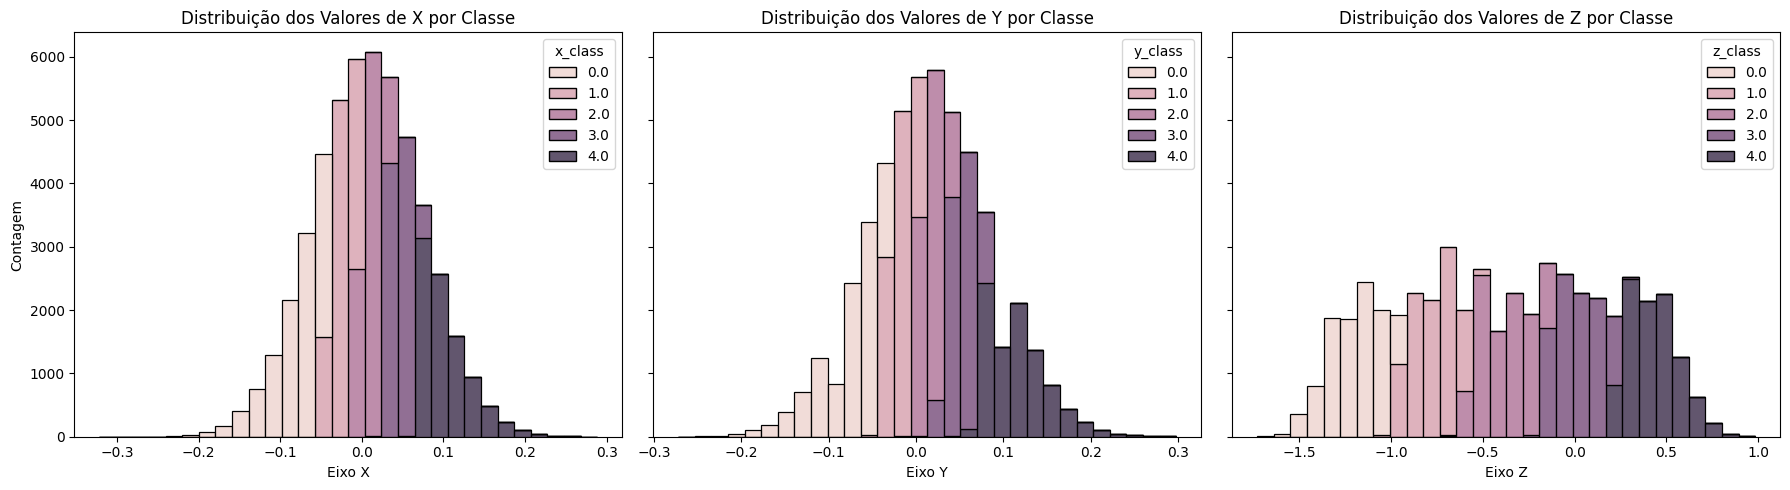

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o layout para mostrar 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Histograma para o eixo X
sns.histplot(data=df, x='x', hue='x_class', multiple='stack', bins=30, ax=axes[0])
axes[0].set_xlabel('Eixo X')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição dos Valores de X por Classe')

# Histograma para o eixo Y
sns.histplot(data=df, x='y', hue='y_class', multiple='stack', bins=30, ax=axes[1])
axes[1].set_xlabel('Eixo Y')
axes[1].set_ylabel('Contagem')
axes[1].set_title('Distribuição dos Valores de Y por Classe')

# Histograma para o eixo Z
sns.histplot(data=df, x='z', hue='z_class', multiple='stack', bins=30, ax=axes[2])
axes[2].set_xlabel('Eixo Z')
axes[2].set_ylabel('Contagem')
axes[2].set_title('Distribuição dos Valores de Z por Classe')

# Ajustar espaçamento entre os gráficos
plt.tight_layout()
plt.show()

### Código para Regressão (LazyRegressor) em cada eixo

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from lazypredict.Supervised import LazyRegressor

# **1. Carregar os dados do arquivo**
file_path = '../../sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados
df = df.iloc[:50000]

# **2. Configurar o TimeSeriesSplit**
tscv = TimeSeriesSplit(n_splits=5)

# **3. Função para processar cada eixo independentemente**
def process_axis(df, axis_name):
    print(f"\n### Avaliando o eixo {axis_name.upper()} ###")
    
    X = df[[axis_name]]  # Feature: valores do eixo atual
    n = 1  # quantos passos à frente
    y = df[axis_name].shift(-n)
    X = X.iloc[:-n]
    y = y.iloc[:-n]

    # Iterar sobre cada split do TimeSeriesSplit
    split_number = 1
    for train_index, test_index in tscv.split(X):
        print(f"\n--- Processando Split {split_number} para o eixo {axis_name.upper()} ---")
        
        # Criar os conjuntos de treino e teste para esse split
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # **4. Ajustar os modelos usando LazyRegressor**
        reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
        models, _ = reg.fit(X_train, X_test, y_train, y_test)
        
        # Exibir os melhores modelos do LazyRegressor para esse split
        print(f"Modelos avaliados no eixo {axis_name.upper()} - Split {split_number}:")
        print(models)

        split_number += 1

    return models

# **5. Avaliar todos os eixos independentemente**
models_x = process_axis(df, 'x')
models_y = process_axis(df, 'y')
models_z = process_axis(df, 'z')

# **6. Comparação Final dos Modelos**
print("\n### Comparação Final dos Modelos ###")
print(f"Melhores modelos para o eixo X:\n{models_x}")
print(f"Melhores modelos para o eixo Y:\n{models_y}")
print(f"Melhores modelos para o eixo Z:\n{models_z}")



### Avaliando o eixo X ###

--- Processando Split 1 para o eixo X ---


100%|██████████| 42/42 [02:33<00:00,  3.66s/it]


Modelos avaliados no eixo X - Split 1:
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
TransformedTargetRegressor                   0.06       0.06  0.06        0.01
OrthogonalMatchingPursuit                    0.06       0.06  0.06        0.00
Lars                                         0.06       0.06  0.06        0.01
LinearRegression                             0.06       0.06  0.06        0.00
LarsCV                                       0.06       0.06  0.06        0.01
LassoLarsIC                                  0.06       0.06  0.06        0.00
LassoLarsCV                                  0.06       0.06  0.06        0.01
Ridge                                        0.06       0.06  0.06        0.01
LassoCV                                      0.06       0.06  0.06        0.03
ElasticNetCV                                 0.06       0.06  0.06        0.02
RidgeCV      

100%|██████████| 42/42 [09:51<00:00, 14.09s/it]


Modelos avaliados no eixo X - Split 2:
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
SGDRegressor                                 0.06       0.06  0.06        0.01
TransformedTargetRegressor                   0.06       0.06  0.06        0.01
OrthogonalMatchingPursuit                    0.06       0.06  0.06        0.01
LassoLarsIC                                  0.06       0.06  0.06        0.01
LarsCV                                       0.06       0.06  0.06        0.02
LassoLarsCV                                  0.06       0.06  0.06        0.01
Lars                                         0.06       0.06  0.06        0.01
LinearRegression                             0.06       0.06  0.06        0.00
Ridge                                        0.06       0.06  0.06        0.01
RidgeCV                                      0.06       0.06  0.06        0.00
BayesianRidge

...

Modelos avaliados no eixo Z - Split 3:
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
GradientBoostingRegressor                    0.97       0.97  0.10        0.41
HistGradientBoostingRegressor                0.97       0.97  0.10        0.40
LGBMRegressor                                0.97       0.97  0.10        0.16
XGBRegressor                                 0.97       0.97  0.10        0.08
RandomForestRegressor                        0.97       0.97  0.10        0.43
DecisionTreeRegressor                        0.97       0.97  0.10        0.01
ExtraTreeRegressor                           0.97       0.97  0.10        0.01
ExtraTreesRegressor                          0.97       0.97  0.10        0.27
BaggingRegressor                             0.97       0.97  0.10        0.05
SVR                                          0.97       0.97  0.10        5.81
MLPRegressor 

100%|██████████| 42/42 [36:45<00:00, 52.51s/it] 


Modelos avaliados no eixo Z - Split 4:
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
HistGradientBoostingRegressor                0.97       0.97  0.10        0.51
GradientBoostingRegressor                    0.97       0.97  0.10        0.54
LGBMRegressor                                0.97       0.97  0.10        0.17
BaggingRegressor                             0.97       0.97  0.10        0.06
ExtraTreesRegressor                          0.97       0.97  0.10        0.33
RandomForestRegressor                        0.97       0.97  0.10        0.54
SVR                                          0.97       0.97  0.10        7.80
NuSVR                                        0.97       0.97  0.10       27.57
DecisionTreeRegressor                        0.97       0.97  0.10        0.01
ExtraTreeRegressor                           0.97       0.97  0.10        0.01
XGBRegressor 

100%|██████████| 42/42 [57:13<00:00, 81.75s/it] 

Modelos avaliados no eixo Z - Split 5:
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
BaggingRegressor                             0.97       0.97  0.10        0.07
RandomForestRegressor                        0.97       0.97  0.10        0.64
GradientBoostingRegressor                    0.97       0.97  0.10        0.68
DecisionTreeRegressor                        0.97       0.97  0.10        0.01
ExtraTreeRegressor                           0.97       0.97  0.10        0.01
ExtraTreesRegressor                          0.97       0.97  0.10        0.38
LGBMRegressor                                0.97       0.97  0.10        0.18
XGBRegressor                                 0.97       0.97  0.10        0.07
HistGradientBoostingRegressor                0.97       0.97  0.10        0.46
SVR                                          0.97       0.97  0.10       10.94
NuSVR        

# teste

## Verificando se os dados são idêncitcos

In [ ]:
# Chamar a função process_axis() e capturar os dados do último split
def get_last_split(df, axis_name):
    X = df[[axis_name]]
    n = 1  # quantos passos à frente
    y = df[axis_name].shift(-n)
    X = X.iloc[:-n]
    y = y.iloc[:-n]
    
    tscv = TimeSeriesSplit(n_splits=5)
    
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    return X_train, y_train

# Obter os últimos splits de X_train e y_train
X_train_x, y_train_x = get_last_split(df, 'x')

# Verificar se os dados são idênticos
print("Os dados de X_train e y_train são idênticos?",
      np.array_equal(X_train_x.values, y_train_x.values))

# Exibir algumas amostras para conferência manual
print("Primeiros 5 valores de X_train:", X_train_x.head().values.ravel())
print("Primeiros 5 valores de y_train:", y_train_x.head().values.ravel())
print("Últimos 5 valores de X_train:", X_train_x.tail().values.ravel())
print("Últimos 5 valores de y_train:", y_train_x.tail().values.ravel())

Os dados de X_train e y_train são idênticos? False
Primeiros 5 valores de X_train: [-0.02173 -0.02173 -0.02173 -0.00173 -0.06173]
Primeiros 5 valores de y_train: [-0.02173 -0.02173 -0.02173 -0.00173 -0.06173]
Últimos 5 valores de X_train: [ 0.03827  0.03827  0.12827 -0.04173 -0.06173]
Últimos 5 valores de y_train: [ 0.03827  0.03827  0.12827 -0.04173 -0.06173]


In [ ]:
# !pip install statsmodels

## Verificando se os dados são altamente correlacionados

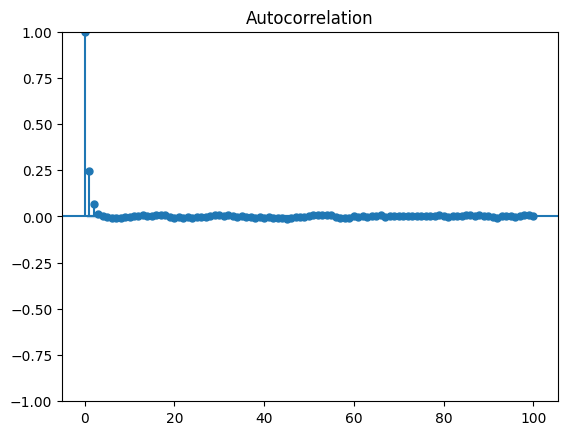

In [15]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['x'], lags=100)  # Teste para o eixo X
plt.show()

In [ ]:
print(df[['x', 'y', 'z']].std())  # Se for muito baixo, há pouca variação

x   0.06
y   0.07
z   0.58
dtype: float64


# Código para Regressão (LazyRegressor) nos 3 eixos simultâneamente

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from lazypredict.Supervised import LazyRegressor

# **1. Carregar os dados**
file_path = '../../sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados
df = df.iloc[:50000]

# **2. Configurar o TimeSeriesSplit**
tscv = TimeSeriesSplit(n_splits=5)

# **3. Criar função para processar os três eixos simultaneamente**
def process_all_axes(df):
    results = {}  # Dicionário para armazenar resultados

    # Definir as features (X) e os targets (y) para prever o próximo instante
    n=1
    X = df[['x', 'y', 'z']]  # Entrada: estado atual
    # y = df[['x', 'y', 'z']]
    y = df[['x', 'y', 'z']].shift(-n)  # Prever o estado daqui a 5 passos no futuro
    X = X.iloc[:-n]  # Remover as últimas 5 linhas pois não terão target correspondente
    y = y.iloc[:-n]

    split_number = 1  # Contador de splits
    for train_index, test_index in tscv.split(X):
        print(f"\n--- Processando Split {split_number} para X, Y e Z ---")

        # Separar treino e teste
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # **4. Treinar o LazyRegressor para prever os três eixos**
        reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
        models, _ = reg.fit(X_train, X_test, y_train, y_test)

        # Armazenar resultados do split atual
        results[f"Split {split_number}"] = models

        # Exibir os modelos ajustados para esse split
        print(f"Modelos avaliados no Split {split_number}:")
        print(models)

        split_number += 1  # Incrementar contador

    return results

# **5. Executar a função e armazenar os resultados**
all_results = process_all_axes(df)

# **6. Exibir os resultados organizados por split**
for split, models in all_results.items():
    print(f"\n### Resultados do {split} ###")
    print(models)



--- Processando Split 1 para X, Y e Z ---


100%|██████████| 42/42 [00:13<00:00,  3.20it/s]


Modelos avaliados no Split 1:
                            Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                      
Ridge                                     0.37       0.37  0.08        0.01
RidgeCV                                   0.37       0.37  0.08        0.01
LinearRegression                          0.37       0.37  0.08        0.01
Lars                                      0.37       0.37  0.08        0.01
TransformedTargetRegressor                0.37       0.37  0.08        0.01
OrthogonalMatchingPursuit                 0.37       0.37  0.08        0.01
MLPRegressor                              0.34       0.34  0.08        0.18
XGBRegressor                              0.29       0.29  0.08        0.25
KNeighborsRegressor                       0.23       0.23  0.09        0.03
RandomForestRegressor                     0.23       0.23  0.09        1.30
KernelRidge                               0.19       0.19 

100%|██████████| 42/42 [00:27<00:00,  1.54it/s]


Modelos avaliados no Split 2:
                            Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                      
OrthogonalMatchingPursuit                 0.37       0.37  0.08        0.01
Lars                                      0.37       0.37  0.08        0.01
LinearRegression                          0.37       0.37  0.08        0.01
TransformedTargetRegressor                0.37       0.37  0.08        0.01
RidgeCV                                   0.37       0.37  0.08        0.01
Ridge                                     0.37       0.37  0.08        0.01
MLPRegressor                              0.35       0.35  0.08        0.33
XGBRegressor                              0.33       0.33  0.08        0.33
KNeighborsRegressor                       0.24       0.25  0.09        0.04
RandomForestRegressor                     0.24       0.24  0.09        2.32
KernelRidge                               0.21       0.21 

...

Modelos avaliados no Split 3:
                            Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                      
OrthogonalMatchingPursuit                 0.37       0.37  0.08        0.01
LinearRegression                          0.37       0.37  0.08        0.01
TransformedTargetRegressor                0.37       0.37  0.08        0.01
Lars                                      0.37       0.37  0.08        0.01
RidgeCV                                   0.37       0.37  0.08        0.01
Ridge                                     0.37       0.37  0.08        0.01
MLPRegressor                              0.36       0.36  0.08        0.44
XGBRegressor                              0.33       0.33  0.08        0.36
KNeighborsRegressor                       0.24       0.24  0.09        0.04
RandomForestRegressor                     0.23       0.23  0.09        3.22
BaggingRegressor                          0.18       0.18 

100%|██████████| 42/42 [00:09<00:00,  4.34it/s]


Modelos avaliados no Split 4:
                            Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                      
TransformedTargetRegressor                0.37       0.37  0.08        0.01
Lars                                      0.37       0.37  0.08        0.01
LinearRegression                          0.37       0.37  0.08        0.01
RidgeCV                                   0.37       0.37  0.08        0.02
Ridge                                     0.37       0.37  0.08        0.01
OrthogonalMatchingPursuit                 0.37       0.37  0.08        0.01
MLPRegressor                              0.35       0.35  0.08        0.57
XGBRegressor                              0.34       0.34  0.08        0.43
KNeighborsRegressor                       0.24       0.24  0.09        0.05
RandomForestRegressor                     0.22       0.22  0.09        4.40
BaggingRegressor                          0.18       0.18 

100%|██████████| 42/42 [00:11<00:00,  3.61it/s]

Modelos avaliados no Split 5:
                            Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                      
Ridge                                     0.37       0.37  0.08        0.01
RidgeCV                                   0.37       0.37  0.08        0.02
LinearRegression                          0.37       0.37  0.08        0.01
TransformedTargetRegressor                0.37       0.37  0.08        0.01
Lars                                      0.37       0.37  0.08        0.01
OrthogonalMatchingPursuit                 0.37       0.37  0.08        0.01
MLPRegressor                              0.35       0.35  0.08        0.68
XGBRegressor                              0.35       0.35  0.08        0.42
KNeighborsRegressor                       0.24       0.24  0.09        0.05
RandomForestRegressor                     0.21       0.21  0.09        5.24
BaggingRegressor                          0.17       0.17 

# Escolha do modelo, treino, teste e gravação!
LinearRegression, BayesianRidge, e Lars

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression  # Modelo Linear escolhido
from sklearn.metrics import mean_absolute_error
from joblib import dump

# 1. Carregar os dados
file_path = '../../sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados
df = df.iloc[:50000]

# ---------------------------------------------------
# CORREÇÃO: Aplicar o shift no alvo (y) para prever
# valores futuros. Por exemplo, prever daqui a 5 steps.
# ---------------------------------------------------
n = 5  # número de passos à frente que desejamos prever

# Definir as features (X) e o alvo (y), removendo as últimas 'n' linhas em X
# e deslocando y para cima (shift negativo), removendo as linhas faltantes.
X = df[['x', 'y', 'z']].iloc[:-n]
y = df[['x', 'y', 'z']].shift(-n).iloc[:-n]

# 2. Configurar o TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# 3. Treinar o modelo escolhido
print("Treinando o modelo para prever valores futuros (usando TimeSeriesSplit)...")
split_number = 1
best_model = LinearRegression()  # Modelo escolhido

for train_index, test_index in tscv.split(X):
    print(f"\n--- Processando Split {split_number} ---")

    # Dividir os dados em treino e teste
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Ajustar o modelo no split atual
    best_model.fit(X_train, y_train)

    # Avaliar o modelo no conjunto de teste
    y_pred = best_model.predict(X_test)
    
    # Cálculo do MAE por eixo (x, y, z)
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    print(f"MAE por eixo no Split {split_number}: "
          f"X={mae[0]:.4f}, Y={mae[1]:.4f}, Z={mae[2]:.4f}")

    split_number += 1

# 4. Gravar o modelo treinado
model_path = 'best_model_timeseries_Linear_Regression.joblib'
dump(best_model, model_path)
print(f"\nModelo salvo com sucesso em: {model_path}")

Treinando o modelo para prever valores futuros (usando TimeSeriesSplit)...

--- Processando Split 1 ---
MAE por eixo no Split 1: X=0.0517, Y=0.0553, Z=0.2257

--- Processando Split 2 ---
MAE por eixo no Split 2: X=0.0513, Y=0.0562, Z=0.2165

--- Processando Split 3 ---
MAE por eixo no Split 3: X=0.0516, Y=0.0562, Z=0.2071

--- Processando Split 4 ---
MAE por eixo no Split 4: X=0.0522, Y=0.0552, Z=0.2068

--- Processando Split 5 ---
MAE por eixo no Split 5: X=0.0527, Y=0.0557, Z=0.2134

Modelo salvo com sucesso em: best_model_timeseries_Linear_Regression.joblib


### Carregando o modelo, carregando novos dados Sensor1 e validando

In [62]:
from joblib import load

# **1. Carregar o modelo salvo**
loaded_model = load('best_model_timeseries_Linear_Regression.joblib')
print("Modelo carregado com sucesso!")

# **2. Validar com novos dados**
file_path_new = '../../sensor_data GY-87_1.1.txt'
df_new = pd.read_csv(file_path_new, header=None, names=['x', 'y', 'z'])


# Usar apenas os primeiros 50 mil dados
# df_new = df_new.iloc[:50000]

# ---------------------------------------------------
# CORREÇÃO: Aplicar o shift no alvo (y) para prever
# valores futuros. Por exemplo, prever daqui a 5 steps.
# ---------------------------------------------------
n = 1  # número de passos à frente que desejamos prever

# Definir as features (X) e o alvo (y), removendo as últimas 'n' linhas em X
# e deslocando y para cima (shift negativo), removendo as linhas faltantes.
X_new = df_new[['x', 'y', 'z']].iloc[:-n]
y_new = df_new[['x', 'y', 'z']].shift(-n).iloc[:-n]

# Fazer predições com o modelo carregado
y_new_pred = loaded_model.predict(X_new)

# Avaliar o desempenho no novo conjunto
mae_new = mean_absolute_error(y_new, y_new_pred, multioutput='raw_values')
print(f"MAE nos novos dados: X={mae_new[0]:.4f}, Y={mae_new[1]:.4f}, Z={mae_new[2]:.4f}")


Modelo carregado com sucesso!
MAE nos novos dados: X=0.0572, Y=0.2056, Z=0.0447


### 1. Checando se os novos dados são realmente diferentes

In [44]:
file_path_train = '../../sensor_data GY-87_1.txt'
df_train = pd.read_csv(file_path_train, header=None, names=['x', 'y', 'z'])

# Comparação básica entre dados de treino e novos dados
print("Os dados de treino e novos dados são iguais?")
print(df_train.equals(df_new))

Os dados de treino e novos dados são iguais?
False


### 2. Validando se os dados de entrada possuem variabilidade

In [45]:
print("Estatísticas dos novos dados:")
print(df_new.describe())

Estatísticas dos novos dados:
               x          y          z
count 1000000.00 1000000.00 1000000.00
mean        0.02       0.21      -0.08
std         0.10       0.15       0.09
min       -64.78     -12.58      -0.49
25%        -0.03       0.09      -0.14
50%         0.02       0.20      -0.09
75%         0.07       0.31      -0.02
max        10.59       2.67       0.32


### 3. Simulando com dados artificiais para testar robustez com dados simulados

In [46]:
import numpy as np

# Criar dados artificiais com ruído
X_artificial = X_new + np.random.normal(0, 0.01, size=X_new.shape)
y_artificial = y_new + np.random.normal(0, 0.01, size=y_new.shape)

# Fazer predição e calcular MAE
y_artificial_pred = loaded_model.predict(X_artificial)
mae_artificial = mean_absolute_error(y_artificial, y_artificial_pred, multioutput='raw_values')
print(f"MAE nos dados artificiais: X={mae_artificial[0]:.4f}, Y={mae_artificial[1]:.4f}, Z={mae_artificial[2]:.4f}")


MAE nos dados artificiais: X=0.0577, Y=0.2057, Z=0.0692


### 4. Normalização e Pré-processamento

In [47]:
from sklearn.preprocessing import StandardScaler

# Aplicar normalização se foi usada no treinamento
scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)  # Use `transform` se o scaler do treino foi salvo
y_new_scaled = scaler.transform(y_new)


### 5. Validação Visual

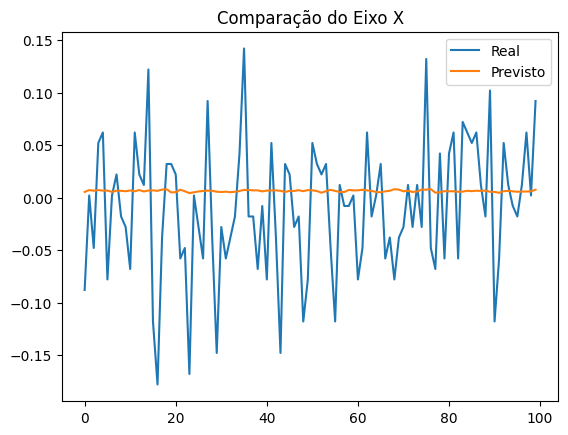

In [48]:
import matplotlib.pyplot as plt

# Comparar eixo X
plt.plot(y_new['x'].values[:100], label='Real')
plt.plot(y_new_pred[:100, 0], label='Previsto')
plt.title('Comparação do Eixo X')
plt.legend()
plt.show()


### Carregando o modelo, carregando novos dados Sensor2 e validando

In [49]:
from joblib import load

# **1. Carregar o modelo salvo**
loaded_model = load('best_model_timeseries_Linear_Regression.joblib')
print("Modelo carregado com sucesso!")

# **2. Validar com novos dados**
file_path_new2 = '../../sensor_data GY-87_2.txt'
df_new2 = pd.read_csv(file_path_new2, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados do novo conjunto
# df_new = df_new.iloc[:50000]
X_new2 = df_new2[['x', 'y', 'z']]
y_new2 = df_new2[['x', 'y', 'z']]

# Fazer predições com o modelo carregado
y_new_pred2 = loaded_model.predict(X_new2)

# Avaliar o desempenho no novo conjunto
mae_new2 = mean_absolute_error(y_new2, y_new_pred2, multioutput='raw_values')
print(f"MAE nos novos dados: X={mae_new2[0]:.4f}, Y={mae_new2[1]:.4f}, Z={mae_new2[2]:.4f}")


Modelo carregado com sucesso!
MAE nos novos dados: X=0.0468, Y=0.0955, Z=0.0586


### 1. Normalização e Pré-processamento

In [50]:
from sklearn.preprocessing import StandardScaler

# Aplicar normalização se foi usada no treinamento
scaler = StandardScaler()
X_new_scaled2 = scaler.fit_transform(X_new2)  # Use `transform` se o scaler do treino foi salvo
y_new_scaled2 = scaler.transform(y_new2)

# Fazer predição com dados normalizados
y_new_pred_scaled2 = loaded_model.predict(X_new_scaled2)

### 2. Validação Visual

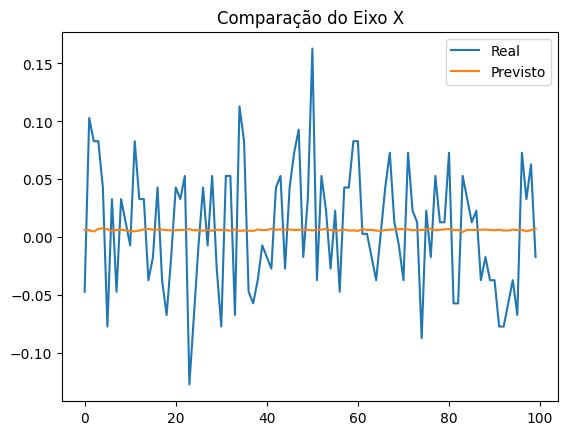

In [51]:
import matplotlib.pyplot as plt

# Comparar eixo X
plt.plot(y_new2['x'].values[:100], label='Real')
plt.plot(y_new_pred2[:100, 0], label='Previsto')
plt.title('Comparação do Eixo X')
plt.legend()
plt.show()

### Carregando o modelo, carregando novos dados Sensor3 e validando

In [52]:
from joblib import load

# **1. Carregar o modelo salvo**
loaded_model = load('best_model_timeseries_Linear_Regression.joblib')
print("Modelo carregado com sucesso!")

# **2. Validar com novos dados**
file_path_new3 = '../../sensor_data GY-87_3.txt'
df_new3 = pd.read_csv(file_path_new3, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados do novo conjunto
# df_new = df_new.iloc[:50000]
X_new3 = df_new3[['x', 'y', 'z']]
y_new3 = df_new3[['x', 'y', 'z']]

# Fazer predições com o modelo carregado
y_new_pred3 = loaded_model.predict(X_new3)

# Avaliar o desempenho no novo conjunto
mae_new3 = mean_absolute_error(y_new3, y_new_pred3, multioutput='raw_values')
print(f"MAE nos novos dados: X={mae_new3[0]:.4f}, Y={mae_new3[1]:.4f}, Z={mae_new3[2]:.4f}")


Modelo carregado com sucesso!
MAE nos novos dados: X=0.0968, Y=0.1346, Z=0.0098


### 1. Normalização e Pré-processamento

In [53]:
from sklearn.preprocessing import StandardScaler

# Aplicar normalização se foi usada no treinamento
scaler = StandardScaler()
X_new_scaled3 = scaler.fit_transform(X_new3)  # Use `transform` se o scaler do treino foi salvo
y_new_scaled3 = scaler.transform(y_new3)

### 2. Validação Visual

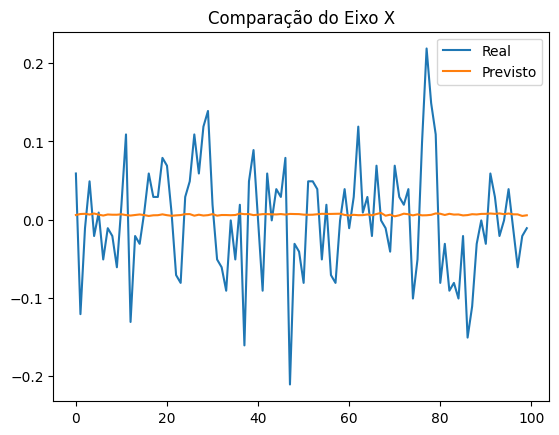

In [54]:
import matplotlib.pyplot as plt

# Comparar eixo X
plt.plot(y_new3['x'].values[:100], label='Real')
plt.plot(y_new_pred3[:100, 0], label='Previsto')
plt.title('Comparação do Eixo X')
plt.legend()
plt.show()

# Verificações Necessárias

Etapa 1: Configuração do Ambiente e Carregamento dos Dados

In [55]:
# !pip install statsmodels

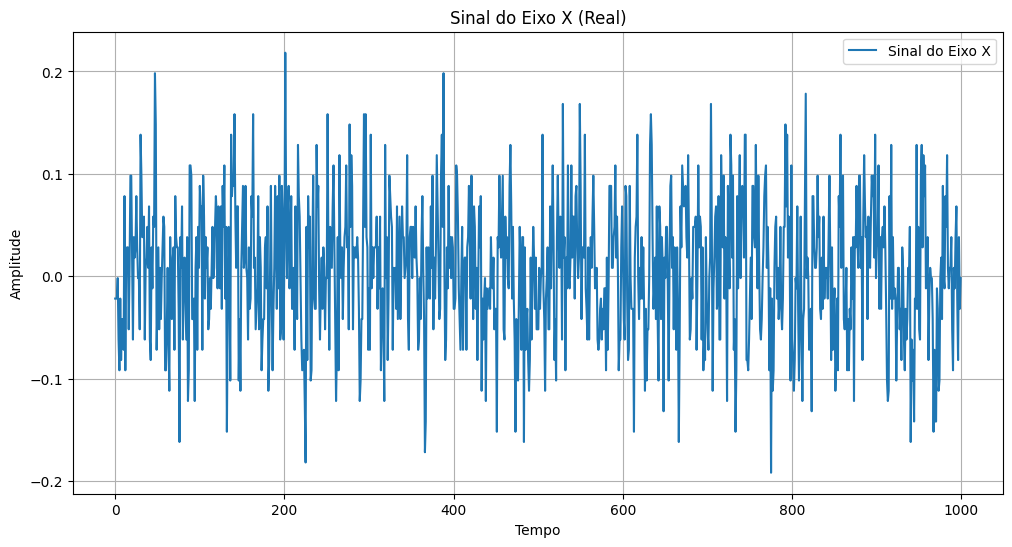

Estatísticas descritivas do eixo X:
count   1000000.00
mean          0.03
std           0.07
min          -0.37
25%          -0.02
50%           0.03
75%           0.07
max           0.51
Name: x, dtype: float64
Média do sinal (X): 0.0267
Desvio padrão do sinal (X): 0.0652
--------------------------------------------------


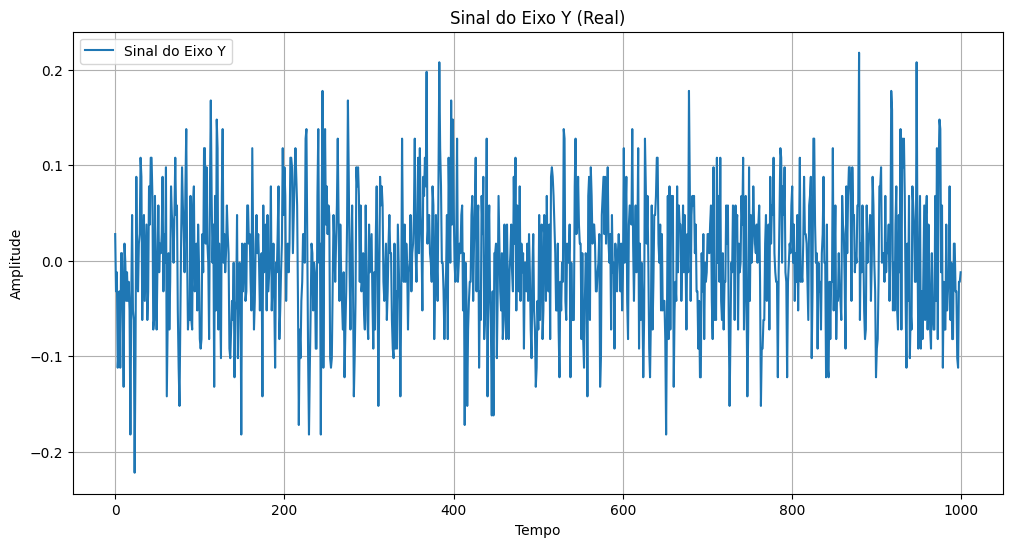

Estatísticas descritivas do eixo Y:
count   1000000.00
mean          0.08
std           0.07
min          -0.27
25%           0.03
50%           0.08
75%           0.13
max           0.45
Name: y, dtype: float64
Média do sinal (Y): 0.0793
Desvio padrão do sinal (Y): 0.0743
--------------------------------------------------


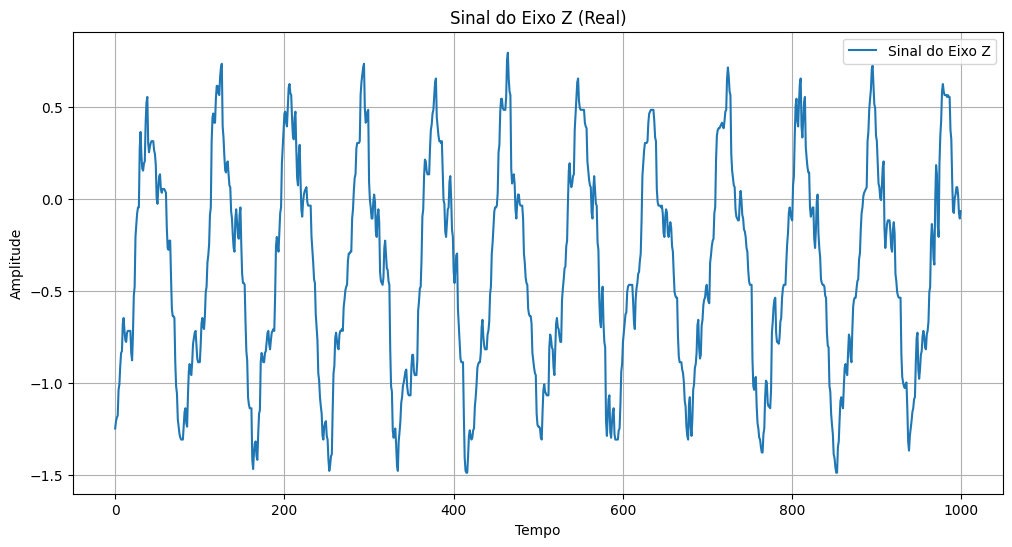

Estatísticas descritivas do eixo Z:
count   1000000.00
mean         -0.29
std           0.59
min          -1.89
25%          -0.77
50%          -0.29
75%           0.20
max           1.51
Name: z, dtype: float64
Média do sinal (Z): -0.2885
Desvio padrão do sinal (Z): 0.5852
--------------------------------------------------


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **1. Carregar os dados reais**
file_path = '../../sensor_data GY-87_1.txt'  # Atualize o caminho se necessário
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])
# df = df.iloc[:100000]  # Usar os primeiros 100.000 pontos

# **2. Análise de cada eixo**
for eixo in ['x', 'y', 'z']:
    signal = df[eixo]

    # **3. Visualizar o sinal original**
    plt.figure(figsize=(12, 6))
    plt.plot(signal[:1000], label=f"Sinal do Eixo {eixo.upper()}")
    plt.title(f"Sinal do Eixo {eixo.upper()} (Real)")
    plt.xlabel("Tempo")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

    # **4. Estatísticas descritivas do sinal**
    print(f"Estatísticas descritivas do eixo {eixo.upper()}:")
    print(signal.describe())

    # **5. Verificação de estacionariedade com a média e variância**
    mean_signal = np.mean(signal)
    std_signal = np.std(signal)
    print(f"Média do sinal ({eixo.upper()}): {mean_signal:.4f}")
    print(f"Desvio padrão do sinal ({eixo.upper()}): {std_signal:.4f}")
    print("-" * 50)


Etapa 2: Determinar o Comportamento Estatístico do Sinal (Ruído)\
Aqui, analisaremos:
1. A distribuição estatística do sinal.
2. O comportamento temporal do ruído (autocorrelação).
3. A natureza espectral do sinal (se necessário).


### Análise do Eixo X ###
Estatísticas descritivas do sinal:
count   100000.00
mean         0.01
std          0.06
min         -0.32
25%         -0.03
50%          0.01
75%          0.06
max          0.29
Name: x, dtype: float64


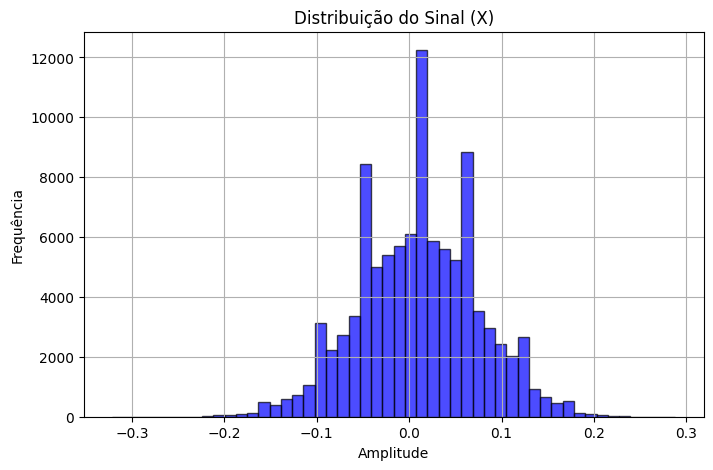

<Figure size 1200x600 with 0 Axes>

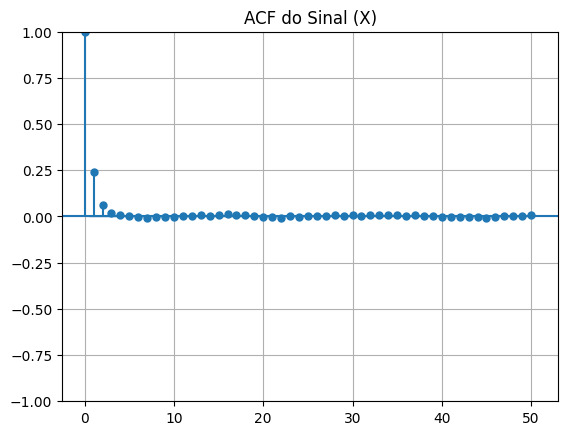

<Figure size 1200x600 with 0 Axes>

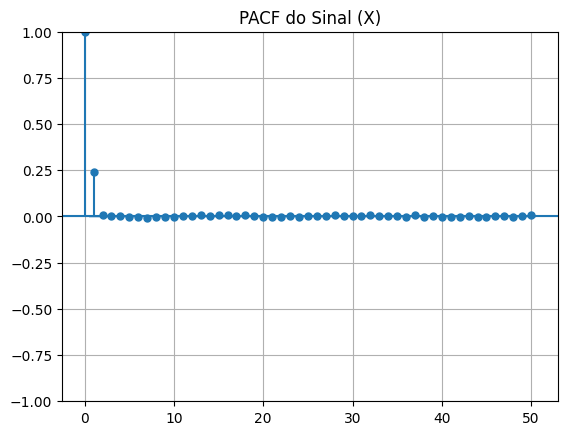

--------------------------------------------------

### Análise do Eixo Y ###
Estatísticas descritivas do sinal:
count   100000.00
mean         0.03
std          0.07
min         -0.27
25%         -0.02
50%          0.03
75%          0.07
max          0.37
Name: y, dtype: float64


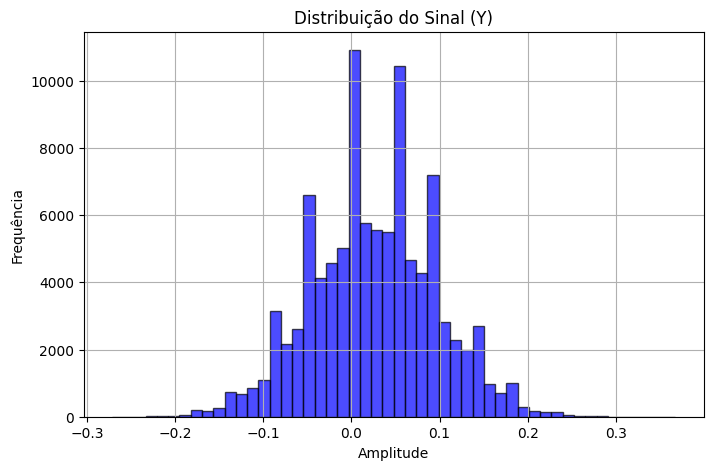

<Figure size 1200x600 with 0 Axes>

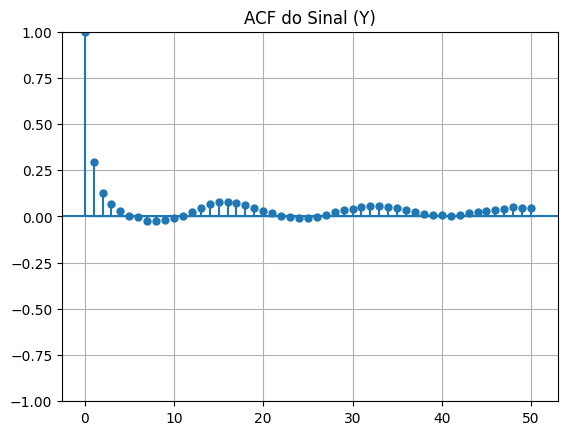

<Figure size 1200x600 with 0 Axes>

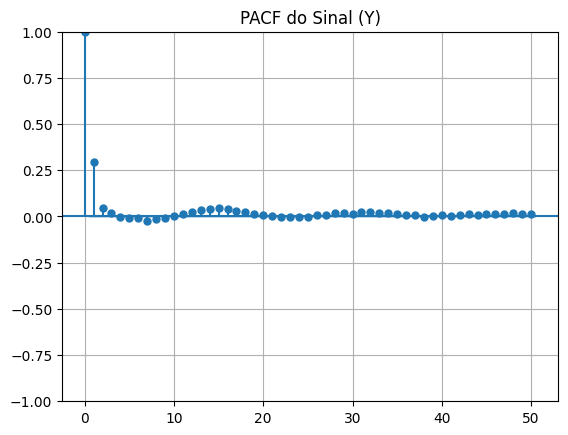

--------------------------------------------------

### Análise do Eixo Z ###
Estatísticas descritivas do sinal:
count   100000.00
mean        -0.38
std          0.58
min         -1.73
25%         -0.88
50%         -0.37
75%          0.11
max          0.98
Name: z, dtype: float64


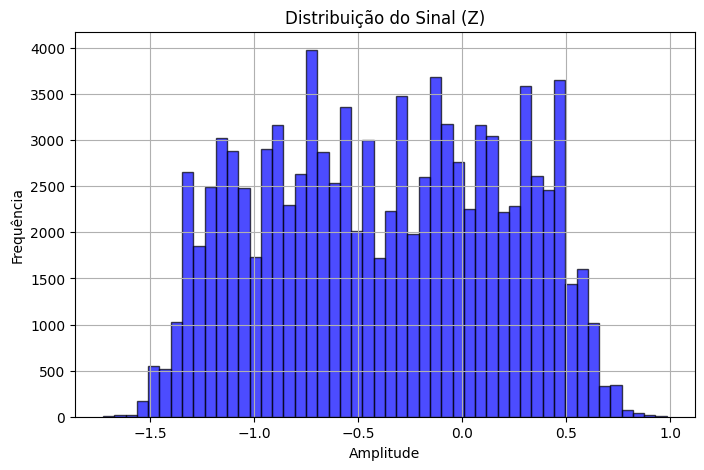

<Figure size 1200x600 with 0 Axes>

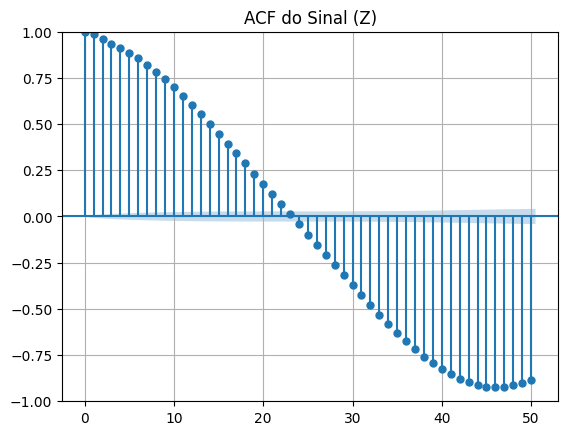

<Figure size 1200x600 with 0 Axes>

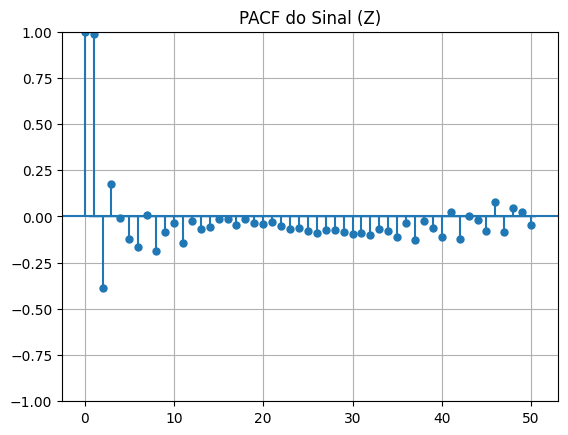

--------------------------------------------------


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# **1. Carregar os dados reais**
file_path = '../../sensor_data GY-87_1.txt'  # Atualize o caminho se necessário
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])
df = df.iloc[:100000]  # Usar os primeiros 100.000 pontos

# **2. Análise para os três eixos**
for eixo in ['x', 'y', 'z']:
    signal = df[eixo]
    
    print(f"\n### Análise do Eixo {eixo.upper()} ###")

    # **1. Estatísticas descritivas**
    print("Estatísticas descritivas do sinal:")
    print(signal.describe())

    # **2. Analisar a distribuição do sinal**
    plt.figure(figsize=(8, 5))
    plt.hist(signal, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Distribuição do Sinal ({eixo.upper()})")
    plt.xlabel("Amplitude")
    plt.ylabel("Frequência")
    plt.grid()
    plt.show()

    # **3. Analisar a autocorrelação (ACF e PACF)**
    plt.figure(figsize=(12, 6))
    plot_acf(signal, lags=50, title=f"ACF do Sinal ({eixo.upper()})")
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plot_pacf(signal, lags=50, title=f"PACF do Sinal ({eixo.upper()})")
    plt.grid()
    plt.show()

    print("-" * 50)


Etapa 3: Modelar o Ruído com Análise Regressiva\
Modelos estatísticos para aproximar a natureza do ruído:
1. Ruído branco (independente e identicamente distribuído).
2. ARIMA (ruído com dependência temporal). ***
3. Ruído Gaussiano (ruído normal).


### Modelagem para o eixo X ###


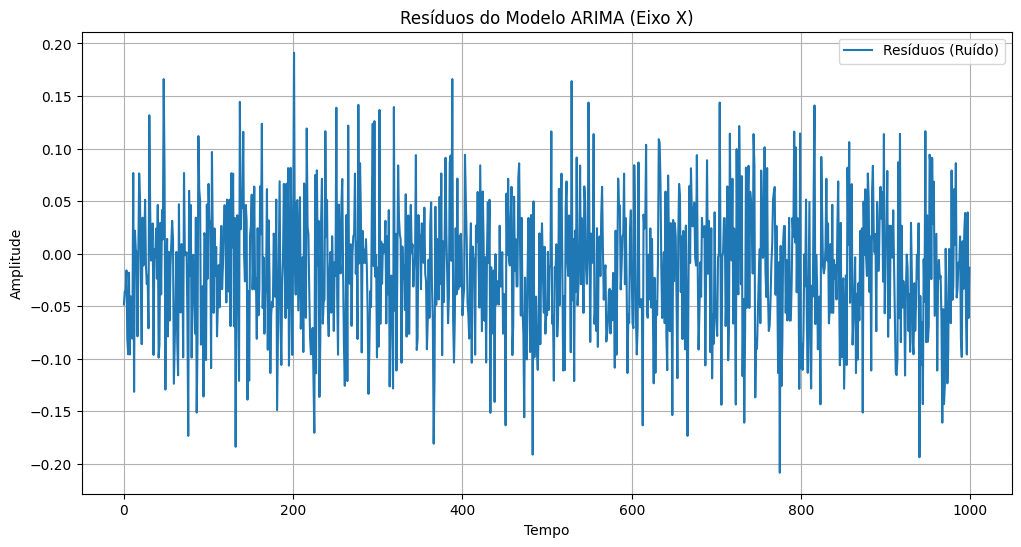

Estatísticas descritivas dos resíduos:
count   1000000.00
mean          0.00
std           0.06
min          -0.38
25%          -0.04
50%           0.00
75%           0.04
max           0.45
dtype: float64

Testes de normalidade:
Shapiro-Wilk: Estatística=0.9999, p-valor=0.0000
D'Agostino: Estatística=11.2452, p-valor=0.0036
--------------------------------------------------

### Modelagem para o eixo Y ###


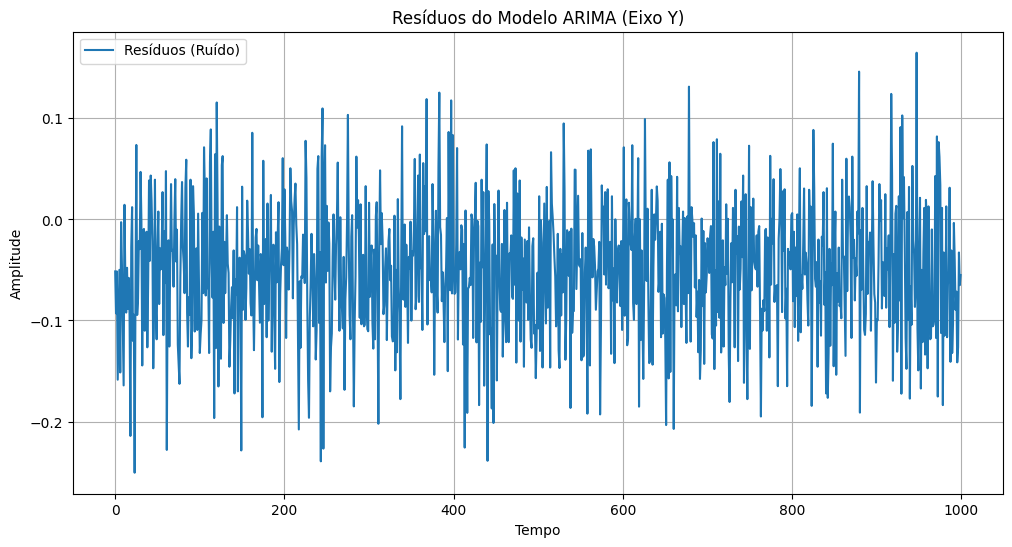

Estatísticas descritivas dos resíduos:
count   1000000.00
mean         -0.00
std           0.07
min          -0.35
25%          -0.05
50%          -0.00
75%           0.05
max           0.35
dtype: float64

Testes de normalidade:
Shapiro-Wilk: Estatística=1.0000, p-valor=0.3984
D'Agostino: Estatística=14.5517, p-valor=0.0007
--------------------------------------------------

### Modelagem para o eixo Z ###


C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


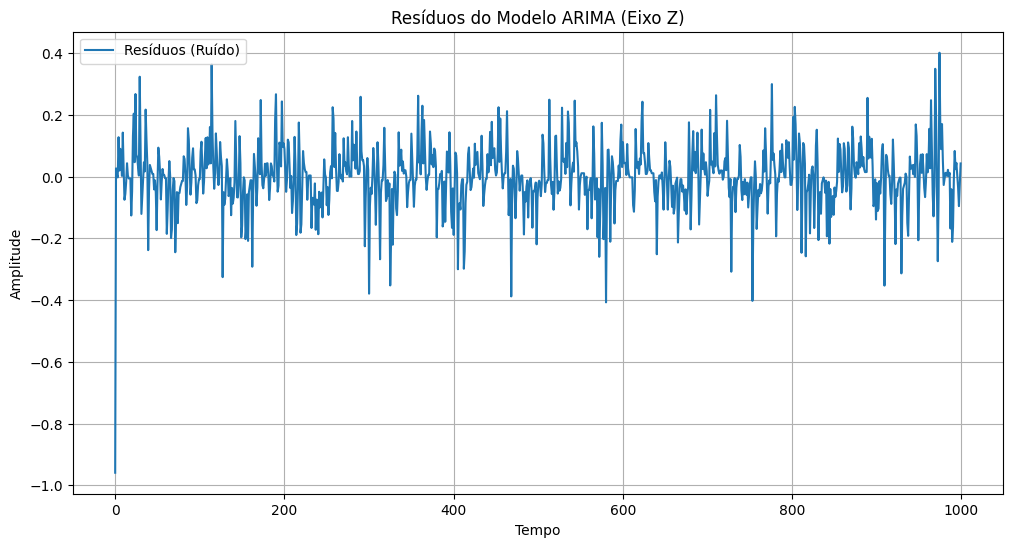

Estatísticas descritivas dos resíduos:
count   1000000.00
mean          0.00
std           0.10
min          -0.96
25%          -0.04
50%           0.00
75%           0.04
max           0.69
dtype: float64

Testes de normalidade:
Shapiro-Wilk: Estatística=0.9565, p-valor=0.0000
D'Agostino: Estatística=65212.3481, p-valor=0.0000
--------------------------------------------------


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import shapiro, normaltest

# **1. Carregar os dados reais**
file_path = '../../sensor_data GY-87_1.txt'  # Atualize o caminho se necessário
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])
# df = df.iloc[:100000]  # Usar os primeiros 100.000 pontos

# **2. Modelagem e análise para cada eixo**
for eixo in ['x', 'y', 'z']:
    signal = df[eixo]
    print(f"\n### Modelagem para o eixo {eixo.upper()} ###")

    # **3. Ajustar um modelo ARIMA ao sinal**
    arima_model = ARIMA(signal, order=(1, 0, 0))  # ARIMA(1,0,0): AR(1)
    arima_fitted = arima_model.fit()

    # **4. Resíduos do modelo (componente de ruído estimado)**
    residuals = arima_fitted.resid

    # **5. Visualizar os resíduos**
    plt.figure(figsize=(12, 6))
    plt.plot(residuals[:1000], label="Resíduos (Ruído)")
    plt.title(f"Resíduos do Modelo ARIMA (Eixo {eixo.upper()})")
    plt.xlabel("Tempo")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

    # **6. Testes estatísticos dos resíduos**
    shapiro_test = shapiro(residuals)
    dagostino_test = normaltest(residuals)

    print("Estatísticas descritivas dos resíduos:")
    print(residuals.describe())

    print("\nTestes de normalidade:")
    print(f"Shapiro-Wilk: Estatística={shapiro_test.statistic:.4f}, p-valor={shapiro_test.pvalue:.4f}")
    print(f"D'Agostino: Estatística={dagostino_test.statistic:.4f}, p-valor={dagostino_test.pvalue:.4f}")

    print("-" * 50)

Etapa 4: Simular Ruído Baseado no Modelo Estimado\
Com base nos resíduos do modelo, podemos gerar ruído artificial que siga a mesma distribuição e dependência temporal observadas.


### Simulação de Ruído para o Eixo X ###


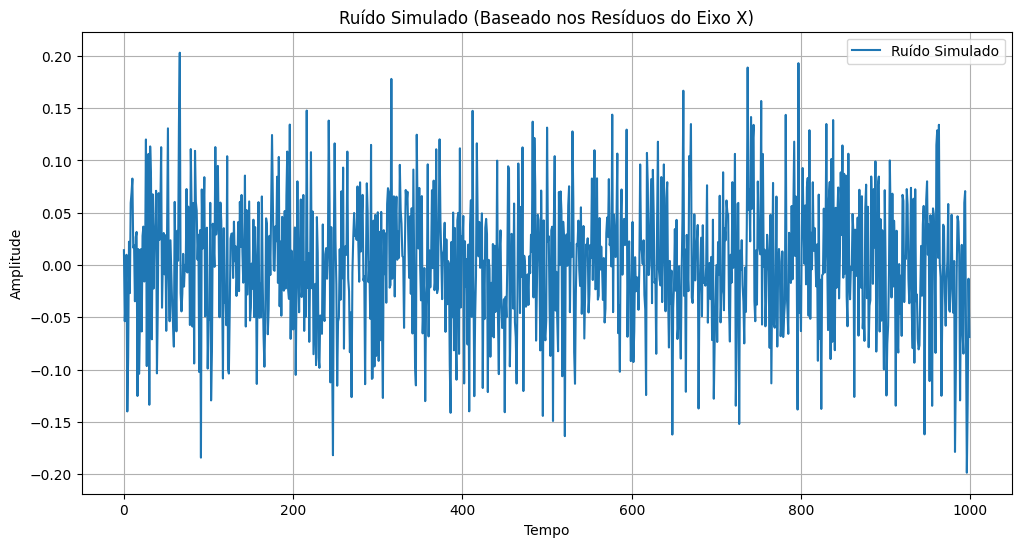

Estatísticas descritivas dos resíduos:
count   1000000.00
mean          0.00
std           0.06
min          -0.38
25%          -0.04
50%           0.00
75%           0.04
max           0.45
dtype: float64

Estatísticas do ruído simulado:
count   1000000.00
mean         -0.00
std           0.06
min          -0.30
25%          -0.04
50%          -0.00
75%           0.04
max           0.30
dtype: float64

Teste KS (Comparação entre resíduos reais e ruído simulado):
KstestResult(statistic=np.float64(0.005345999999999962), pvalue=np.float64(7.716065205299723e-13), statistic_location=np.float64(0.013314456913660398), statistic_sign=np.int8(-1))
--------------------------------------------------

### Simulação de Ruído para o Eixo Y ###


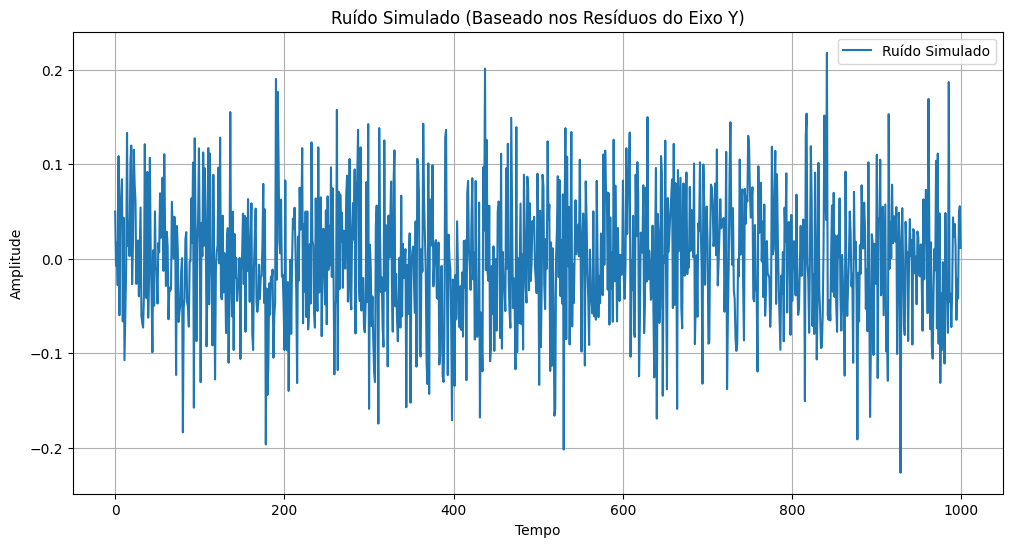

Estatísticas descritivas dos resíduos:
count   1000000.00
mean         -0.00
std           0.07
min          -0.35
25%          -0.05
50%          -0.00
75%           0.05
max           0.35
dtype: float64

Estatísticas do ruído simulado:
count   1000000.00
mean          0.00
std           0.07
min          -0.33
25%          -0.05
50%           0.00
75%           0.05
max           0.35
dtype: float64

Teste KS (Comparação entre resíduos reais e ruído simulado):
KstestResult(statistic=np.float64(0.002343000000000095), pvalue=np.float64(0.008245661638665554), statistic_location=np.float64(0.014721609326418552), statistic_sign=np.int8(-1))
--------------------------------------------------

### Simulação de Ruído para o Eixo Z ###


C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


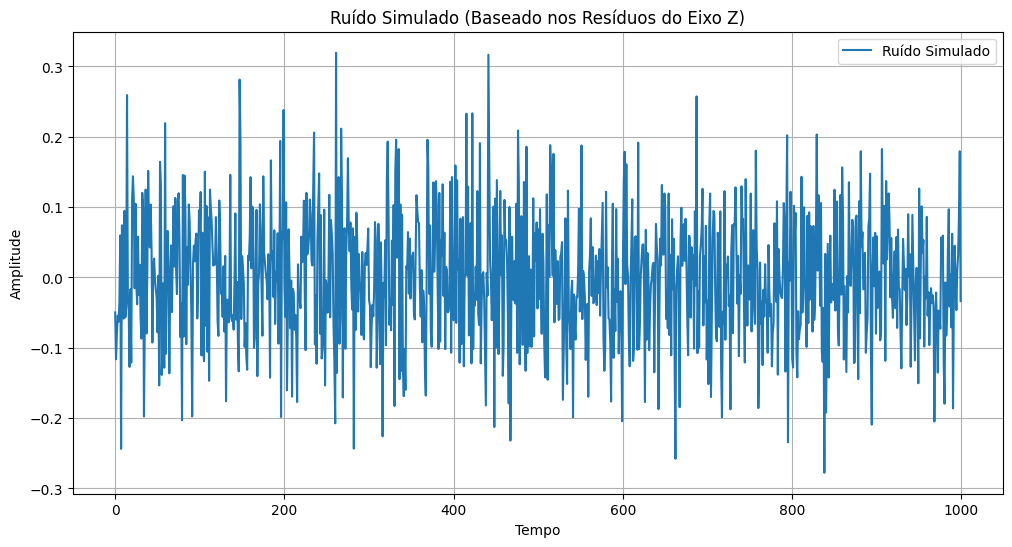

Estatísticas descritivas dos resíduos:
count   1000000.00
mean          0.00
std           0.10
min          -0.96
25%          -0.04
50%           0.00
75%           0.04
max           0.69
dtype: float64

Estatísticas do ruído simulado:
count   1000000.00
mean         -0.00
std           0.10
min          -0.49
25%          -0.07
50%           0.00
75%           0.07
max           0.49
dtype: float64

Teste KS (Comparação entre resíduos reais e ruído simulado):
KstestResult(statistic=np.float64(0.078186), pvalue=np.float64(0.0), statistic_location=np.float64(-0.04535646529965432), statistic_sign=np.int8(-1))
--------------------------------------------------


In [59]:
# **1. Simular ruído para cada eixo**
for eixo in ['x', 'y', 'z']:
    signal = df[eixo]
    print(f"\n### Simulação de Ruído para o Eixo {eixo.upper()} ###")
    
    # Ajustar o modelo ARIMA para obter os resíduos
    arima_model = ARIMA(signal, order=(1, 0, 0))  # ARIMA(1,0,0): AR(1)
    arima_fitted = arima_model.fit()
    residuals = arima_fitted.resid

    # **2. Gerar ruído com a mesma distribuição dos resíduos**
    simulated_noise = np.random.normal(loc=residuals.mean(), scale=residuals.std(), size=len(signal))

    # **3. Visualizar o ruído simulado**
    plt.figure(figsize=(12, 6))
    plt.plot(simulated_noise[:1000], label="Ruído Simulado")
    plt.title(f"Ruído Simulado (Baseado nos Resíduos do Eixo {eixo.upper()})")
    plt.xlabel("Tempo")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

    # **4. Comparar estatísticas**
    print("Estatísticas descritivas dos resíduos:")
    print(residuals.describe())
    
    print("\nEstatísticas do ruído simulado:")
    print(pd.Series(simulated_noise).describe())

    # **5. Teste KS para comparar ruído real e simulado**
    from scipy.stats import ks_2samp
    ks_test_result = ks_2samp(residuals, simulated_noise)
    print("\nTeste KS (Comparação entre resíduos reais e ruído simulado):")
    print(ks_test_result)
    print("-" * 50)


Etapa 5: Validar o Modelo de Ruído
Para verificar a qualidade do modelo de ruído:
1. Compare as distribuições estatísticas (média, desvio padrão, skewness, kurtosis).
2. Use testes estatísticos para verificar se o ruído simulado é similar ao ruído real.


### Validação de Distribuições para o Eixo X ###
Teste KS (Comparação entre ruído real e simulado): KstestResult(statistic=np.float64(0.005049999999999999), pvalue=np.float64(1.674615043498968e-11), statistic_location=np.float64(-0.008421209652035943), statistic_sign=np.int8(1))


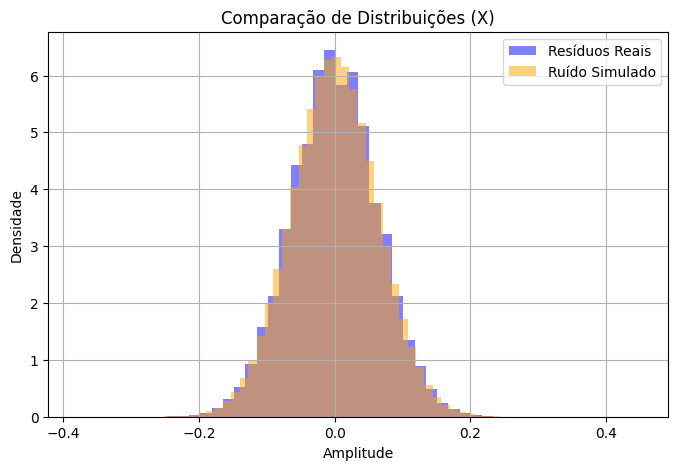

Estatísticas dos resíduos reais (X):
count   1000000.00
mean          0.00
std           0.06
min          -0.38
25%          -0.04
50%           0.00
75%           0.04
max           0.45
dtype: float64

Estatísticas do ruído simulado (X):
count   1000000.00
mean          0.00
std           0.06
min          -0.30
25%          -0.04
50%           0.00
75%           0.04
max           0.32
dtype: float64
--------------------------------------------------

### Validação de Distribuições para o Eixo Y ###
Teste KS (Comparação entre ruído real e simulado): KstestResult(statistic=np.float64(0.0029899999999999927), pvalue=np.float64(0.00026153042167967403), statistic_location=np.float64(-0.0016900651970605013), statistic_sign=np.int8(-1))


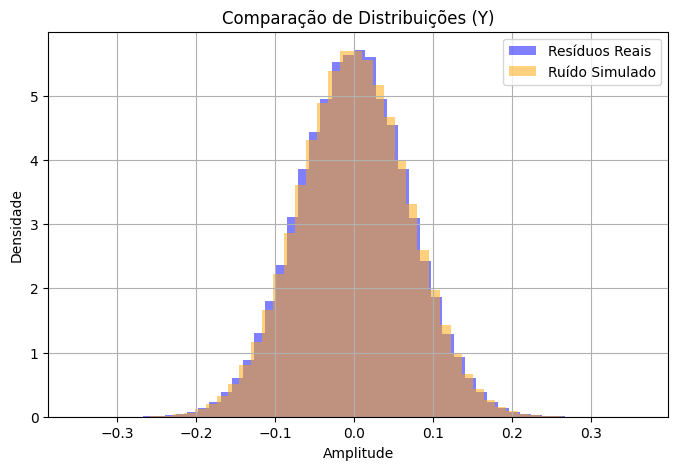

Estatísticas dos resíduos reais (Y):
count   1000000.00
mean         -0.00
std           0.07
min          -0.35
25%          -0.05
50%          -0.00
75%           0.05
max           0.35
dtype: float64

Estatísticas do ruído simulado (Y):
count   1000000.00
mean         -0.00
std           0.07
min          -0.34
25%          -0.05
50%          -0.00
75%           0.05
max           0.36
dtype: float64
--------------------------------------------------

### Validação de Distribuições para o Eixo Z ###


C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Teste KS (Comparação entre ruído real e simulado): KstestResult(statistic=np.float64(0.078766), pvalue=np.float64(0.0), statistic_location=np.float64(-0.044234579076352504), statistic_sign=np.int8(-1))


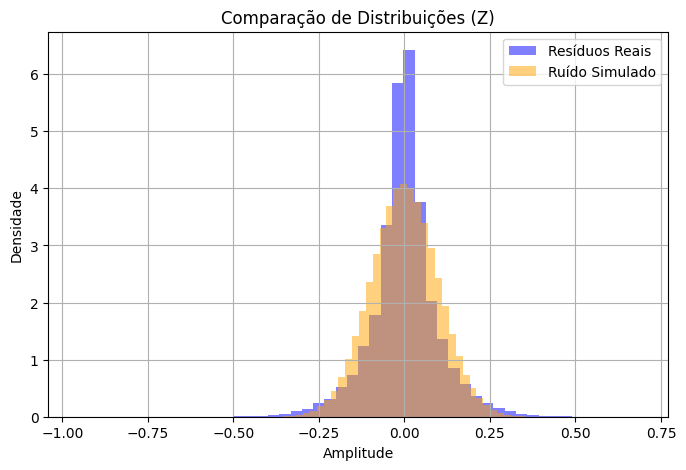

Estatísticas dos resíduos reais (Z):
count   1000000.00
mean          0.00
std           0.10
min          -0.96
25%          -0.04
50%           0.00
75%           0.04
max           0.69
dtype: float64

Estatísticas do ruído simulado (Z):
count   1000000.00
mean         -0.00
std           0.10
min          -0.44
25%          -0.07
50%          -0.00
75%           0.07
max           0.57
dtype: float64
--------------------------------------------------


In [60]:
from scipy.stats import ks_2samp
from scipy.stats import ks_2samp

# **1. Validar e comparar distribuições para cada eixo**
for eixo in ['x', 'y', 'z']:
    signal = df[eixo]
    print(f"\n### Validação de Distribuições para o Eixo {eixo.upper()} ###")
    
    # Ajustar o modelo ARIMA para obter os resíduos
    arima_model = ARIMA(signal, order=(1, 0, 0))  # ARIMA(1,0,0): AR(1)
    arima_fitted = arima_model.fit()
    residuals = arima_fitted.resid

    # **2. Gerar ruído com a mesma distribuição dos resíduos**
    simulated_noise = np.random.normal(loc=residuals.mean(), scale=residuals.std(), size=len(signal))

    # **3. Teste KS para comparar distribuições**
    ks_test = ks_2samp(residuals, simulated_noise)
    print("Teste KS (Comparação entre ruído real e simulado):", ks_test)

    # **4. Plotar sobreposição das distribuições**
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=50, alpha=0.5, label="Resíduos Reais", density=True, color='blue')
    plt.hist(simulated_noise, bins=50, alpha=0.5, label="Ruído Simulado", density=True, color='orange')
    plt.title(f"Comparação de Distribuições ({eixo.upper()})")
    plt.xlabel("Amplitude")
    plt.ylabel("Densidade")
    plt.legend()
    plt.grid()
    plt.show()

    # **5. Estatísticas descritivas**
    print(f"Estatísticas dos resíduos reais ({eixo.upper()}):")
    print(residuals.describe())
    print(f"\nEstatísticas do ruído simulado ({eixo.upper()}):")
    print(pd.Series(simulated_noise).describe())
    print("-" * 50)

## Testando o modelo nos dados simulados em X,Y,Z

Modelo carregado com sucesso!
Predições realizadas com sucesso!
MAE nos dados simulados: X=0.0508, Y=0.0657, Z=0.0422


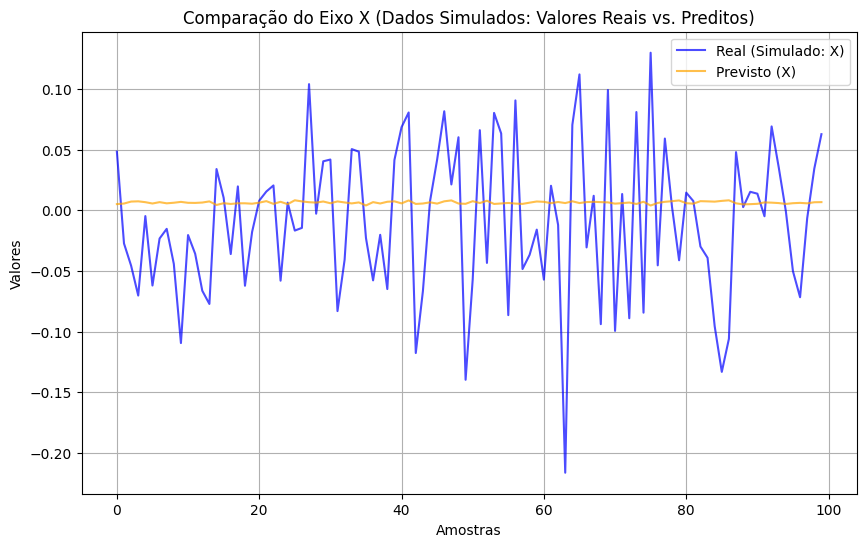

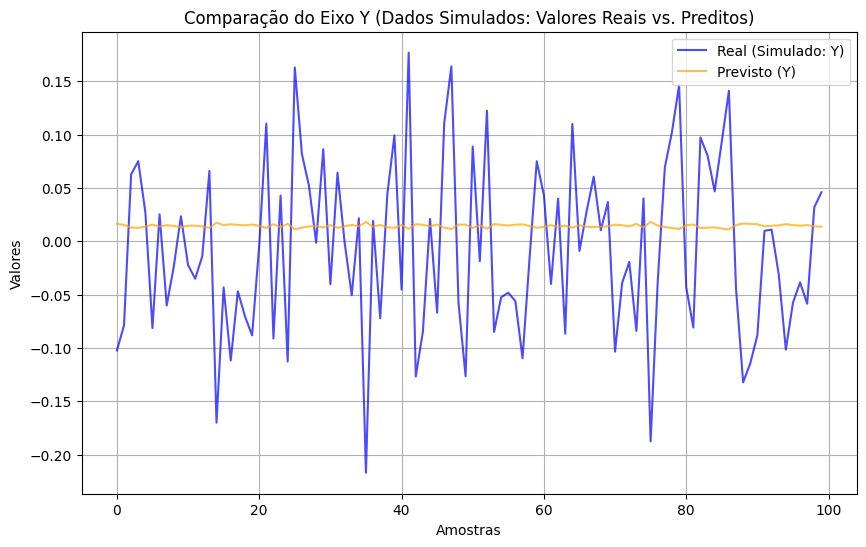

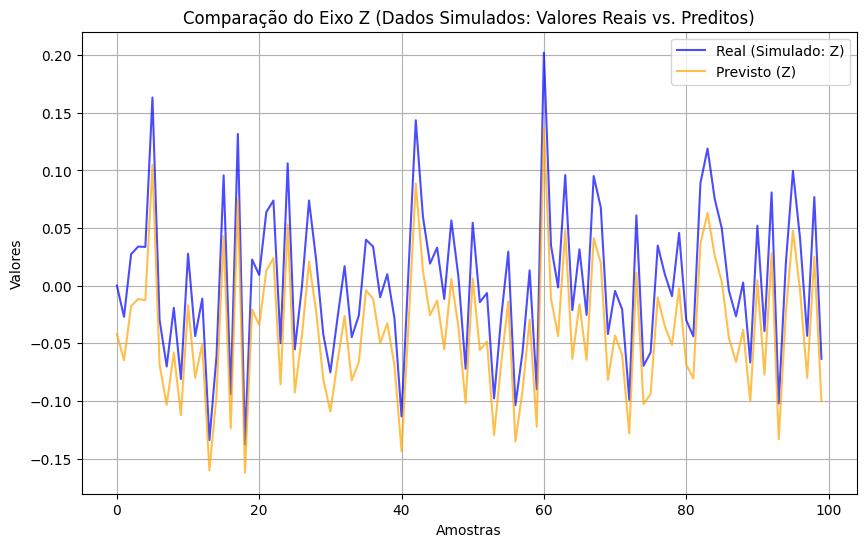

In [61]:
from joblib import load
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# **1. Carregar o modelo salvo**
try:
    loaded_model = load('best_model_timeseries_Linear_Regression.joblib')
    print("Modelo carregado com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivo do modelo não encontrado.")
    exit()

# **2. Gerar os dados simulados com variações para x, y e z**
# Parâmetros para simulação
n_samples = 50000  # Número de amostras simuladas

# Parâmetros de ruído baseados nos resíduos de um eixo (corrigir para cada eixo)
residuals_x_mean, residuals_x_std = 0.0, 0.063  # Ajustar conforme necessário
residuals_y_mean, residuals_y_std = 0.0, 0.08   # Ajustar conforme necessário
residuals_z_mean, residuals_z_std = 0.0, 0.07   # Ajustar conforme necessário

# Criar ruído para cada eixo
simulated_noise_x = np.random.normal(loc=residuals_x_mean, scale=residuals_x_std, size=n_samples)
simulated_noise_y = np.random.normal(loc=residuals_y_mean, scale=residuals_y_std, size=n_samples)
simulated_noise_z = np.random.normal(loc=residuals_z_mean, scale=residuals_z_std, size=n_samples)

# Criar um DataFrame para os dados simulados
df_simulated = pd.DataFrame({
    'x': simulated_noise_x,
    'y': simulated_noise_y,
    'z': simulated_noise_z
})

# Separar as features (X) e os targets (y) dos dados simulados
X_simulated = df_simulated[['x', 'y', 'z']]
y_simulated = df_simulated[['x', 'y', 'z']]

# **3. Fazer predições com o modelo carregado**
try:
    y_simulated_pred = loaded_model.predict(X_simulated)
    print("Predições realizadas com sucesso!")
except Exception as e:
    print(f"Erro ao realizar predições: {e}")
    exit()

# **4. Avaliar o desempenho nos dados simulados**
mae_simulated = mean_absolute_error(y_simulated, y_simulated_pred, multioutput='raw_values')
print(f"MAE nos dados simulados: X={mae_simulated[0]:.4f}, Y={mae_simulated[1]:.4f}, Z={mae_simulated[2]:.4f}")

# **5. Plotar comparação entre valores reais e previstos para cada eixo**
for eixo, i in zip(['x', 'y', 'z'], range(3)):
    plt.figure(figsize=(10, 6))
    plt.plot(y_simulated[eixo][:100], label=f'Real (Simulado: {eixo.upper()})', alpha=0.7, color='blue')
    plt.plot(y_simulated_pred[:100, i], label=f'Previsto ({eixo.upper()})', alpha=0.7, color='orange')
    plt.title(f"Comparação do Eixo {eixo.upper()} (Dados Simulados: Valores Reais vs. Preditos)")
    plt.xlabel("Amostras")
    plt.ylabel("Valores")
    plt.legend()
    plt.grid(True)
    plt.show()
